AI Career Salary Prediction and Job Market Analytics using Machine Learning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/content/global_ai_jobs.csv")
df.head()

,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,...,27.0,12.0,76.0,57.0,65.0,73.0,15.0,55.0,1.23,76.0
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,...,27.0,54.0,29.0,69.0,60.0,51.0,15.0,58.0,0.87,67.0
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,PhD,Healthcare,...,13.0,12.0,49.0,70.0,59.0,68.0,37.0,13.0,2.13,61.0
3,4,India,Software Engineer AI,Computer Vision,Senior,6,43268,7975,Diploma,Tech,...,30.0,80.0,47.0,79.0,65.0,55.0,46.0,74.0,1.49,56.0
4,5,Germany,Machine Learning Engineer,Computer Vision,Entry,0,69119,4758,Master,Retail,...,24.0,82.0,47.0,64.0,52.0,69.0,17.0,21.0,0.87,72.0


In [ ]:
df.columns

Index(['id', 'country', 'job_role', 'ai_specialization', 'experience_level',
       'experience_years', 'salary_usd', 'bonus_usd', 'education_required',
       'industry', 'company_size', 'interview_rounds', 'year', 'work_mode',
       'weekly_hours', 'company_rating', 'job_openings',
       'hiring_difficulty_score', 'layoff_risk', 'ai_adoption_score',
       'company_funding_billion', 'economic_index', 'ai_maturity_years',
       'offer_acceptance_rate', 'tax_rate_percent', 'vacation_days',
       'skill_demand_score', 'automation_risk', 'job_security_score',
       'career_growth_score', 'work_life_balance_score', 'promotion_speed',
       'salary_percentile', 'cost_of_living_index', 'employee_satisfaction'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26821 entries, 0 to 26820
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       26821 non-null  int64  
 1   country                  26821 non-null  object 
 2   job_role                 26821 non-null  object 
 3   ai_specialization        26821 non-null  object 
 4   experience_level         26821 non-null  object 
 5   experience_years         26821 non-null  int64  
 6   salary_usd               26821 non-null  int64  
 7   bonus_usd                26821 non-null  int64  
 8   education_required       26821 non-null  object 
 9   industry                 26821 non-null  object 
 10  company_size             26820 non-null  object 
 11  interview_rounds         26820 non-null  float64
 12  year                     26820 non-null  float64
 13  work_mode                26820 non-null  object 
 14  weekly_hours          

In [ ]:
df.describe(include="object")

,country,job_role,ai_specialization,experience_level,education_required,industry,company_size,work_mode
count,26821,26821,26821,26821,26821,26821,26820,26820
unique,12,8,8,4,5,11,5,3
top,Brazil,Data Scientist,LLM,Senior,Bachelor,Energy,Startup,Onsite
freq,2339,3432,3412,6754,5432,2765,5444,9072


In [ ]:
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 0


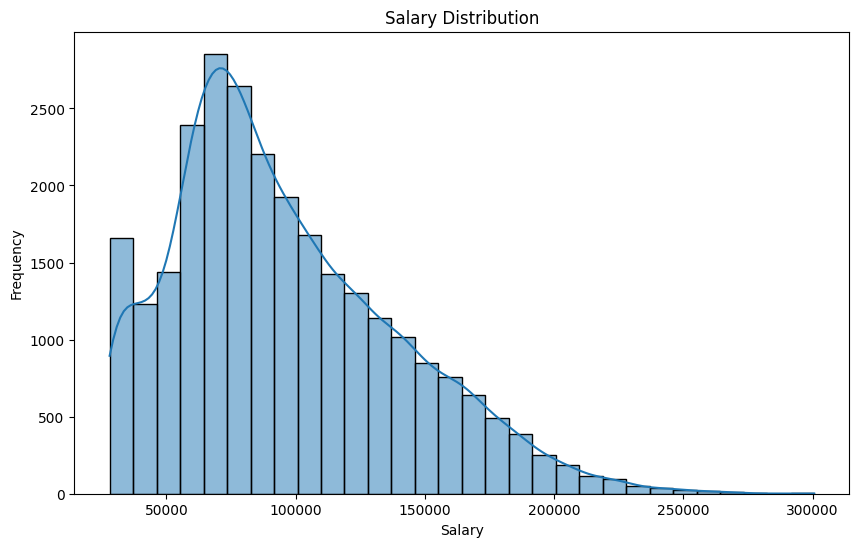

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df["salary_usd"], bins=30, kde=True)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

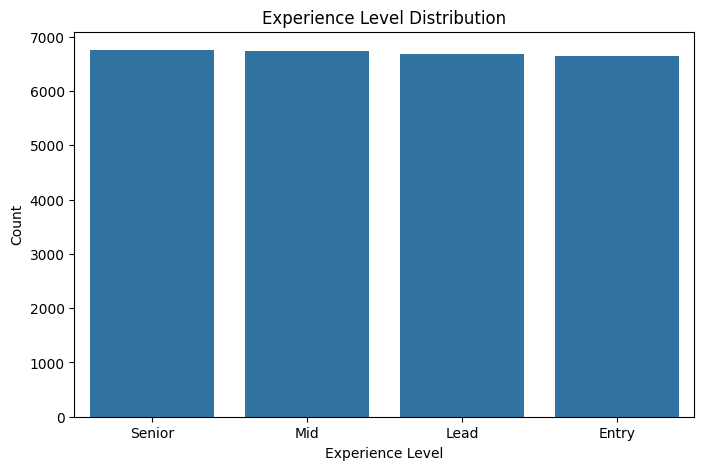

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(
    x=df["experience_level"],
    order=df["experience_level"].value_counts().index
)
plt.title("Experience Level Distribution")
plt.xlabel("Experience Level")
plt.ylabel("Count")
plt.show()

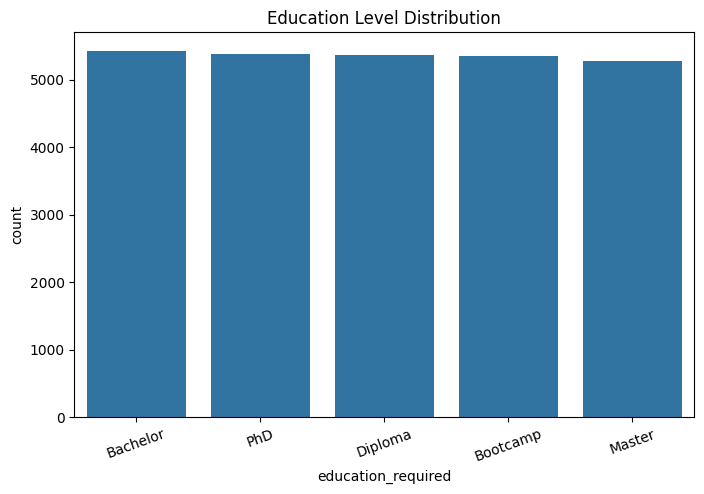

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["education_required"],
    order=df["education_required"].value_counts().index
)

plt.title("Education Level Distribution")

plt.xticks(rotation=20)

plt.show()

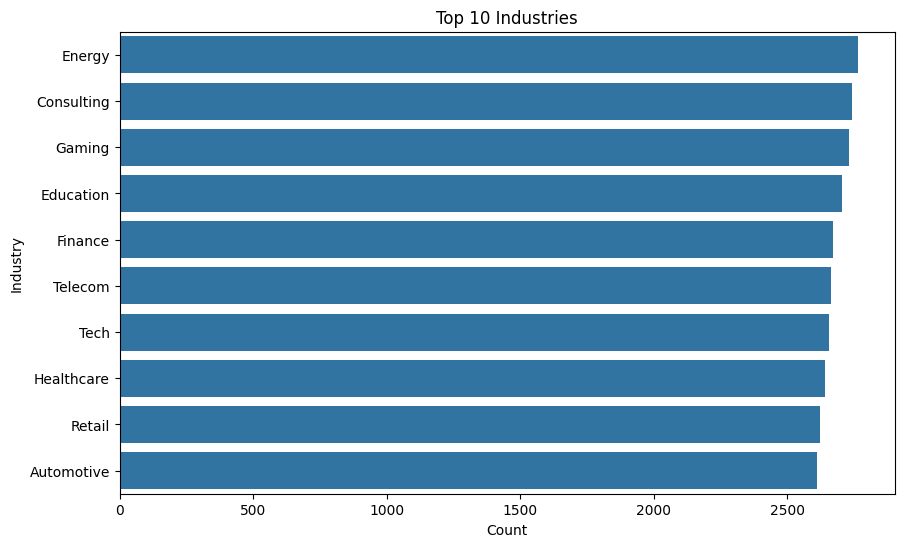

In [ ]:
plt.figure(figsize=(10,6))

industry = df["industry"].value_counts().head(10)
sns.barplot(
    x=industry.values,
    y=industry.index
)

plt.title("Top 10 Industries")

plt.xlabel("Count")

plt.ylabel("Industry")

plt.show()

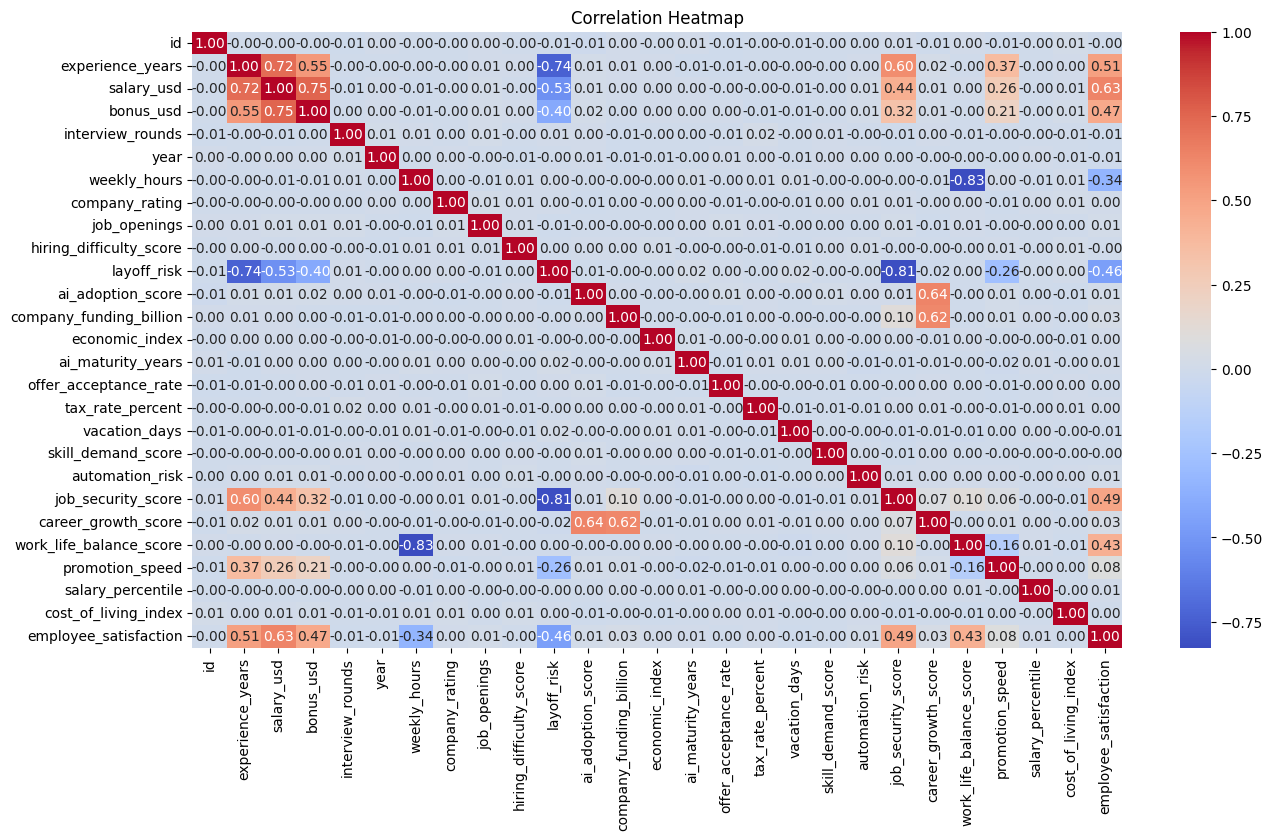

In [ ]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(15,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
target = "salary_usd"

X = df.drop(columns=[target])
y = df[target]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (26821, 34)
Target Shape : (26821,)


In [ ]:
categorical_columns = X.select_dtypes(include=["object"]).columns

numerical_columns = X.select_dtypes(exclude=["object"]).columns

print("Categorical Columns")
print(categorical_columns)

print("\nNumerical Columns")
print(numerical_columns)

Categorical Columns
Index(['country', 'job_role', 'ai_specialization', 'experience_level',
       'education_required', 'industry', 'company_size', 'work_mode'],
      dtype='object')

Numerical Columns
Index(['id', 'experience_years', 'bonus_usd', 'interview_rounds', 'year',
       'weekly_hours', 'company_rating', 'job_openings',
       'hiring_difficulty_score', 'layoff_risk', 'ai_adoption_score',
       'company_funding_billion', 'economic_index', 'ai_maturity_years',
       'offer_acceptance_rate', 'tax_rate_percent', 'vacation_days',
       'skill_demand_score', 'automation_risk', 'job_security_score',
       'career_growth_score', 'work_life_balance_score', 'promotion_speed',
       'salary_percentile', 'cost_of_living_index', 'employee_satisfaction'],
      dtype='object')


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

print("Preprocessor Created Successfully")

Preprocessor Created Successfully


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (21456, 34)
Testing Data : (5365, 34)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

print("Models Created Successfully")

Models Created Successfully


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Redefine categorical and numerical columns (assuming X is available from previous cells)
categorical_columns = X.select_dtypes(include=["object"]).columns
numerical_columns = X.select_dtypes(exclude=["object"]).columns

# Redefine numeric and categorical transformers
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Redefine preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

results = []

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", model)
        ]
    )

    # Fit the pipeline
    pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred = pipeline.predict(X_test)

    # Evaluate the model
    mae = mean_absolute_error(y_test, y_pred);
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

results_df.sort_values(
    by="R2 Score",
    ascending=False,
    inplace=True
)

print(results_df)

               Model           MAE          RMSE  R2 Score
2      Random Forest   8618.463430  11393.100582  0.932914
3  Gradient Boosting   8738.075296  11454.168987  0.932192
0  Linear Regression  10542.130910  13578.343391  0.904711
1      Decision Tree  11972.213979  16458.282883  0.860003


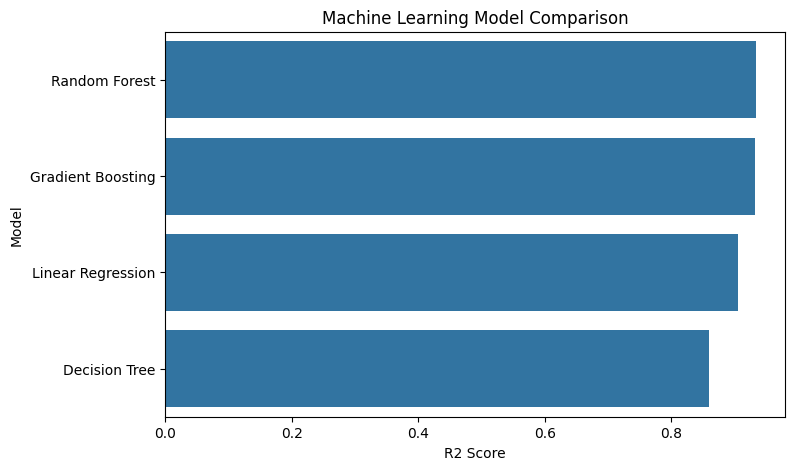

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="R2 Score",
    y="Model"
)

plt.title("Machine Learning Model Comparison")

plt.xlabel("R2 Score")

plt.ylabel("Model")

plt.show()

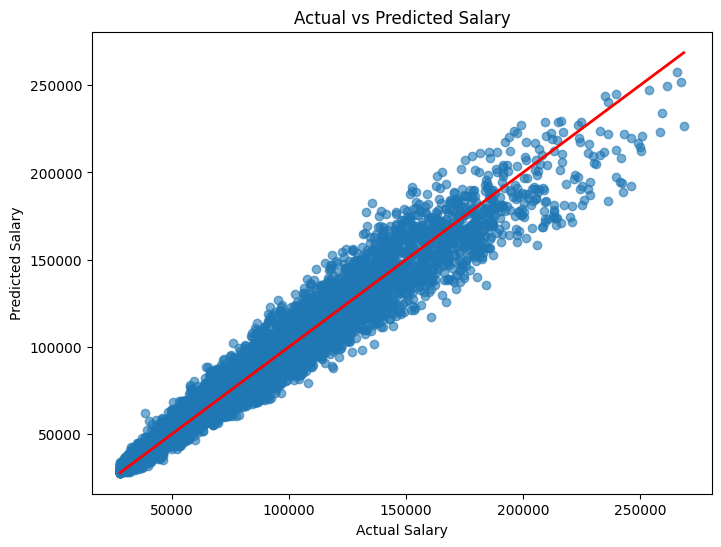

In [ ]:
best_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ]
)

# Train the model
best_pipeline.fit(X_train, y_train)

# Predict
y_pred = best_pipeline.predict(X_test)

# Plot
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

In [ ]:
import joblib

joblib.dump(best_pipeline, "salary_prediction_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:

import joblib

# Load Model
loaded_model = joblib.load("salary_prediction_model.pkl")

# Predict on First Test Sample
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print("="*50)
print("Actual Salary      :", y_test.iloc[0])
print("Predicted Salary   :", round(prediction[0], 2))
print("="*50)

Actual Salary      : 28000
Predicted Salary   : 28318.3
